In [27]:
import matplotlib.pyplot as plt

In [28]:
# import LebwohlLasher_cython.cython.LebwohlLasher_cython.cpython-311-x86_64-linux-gnu as cy
# print([x for x in dir(cy) if "energy" in x.lower() or "order" in x.lower()])
# print(dir(cy))

In [ ]:
implementations = {'initial':'LebwohlLasher.py','numba':'LebwohlLasher_numba.py','numba_parallel':'LebwohlLasher_numba_parrallel.py'}implementations = {'initial':'LebwohlLasher.py','numba':'LebwohlLasher_numba.py','numba_parallel':'LebwohlLasher_numba_parrallel.py'}

In [ ]:
implementations = {'initial':'LebwohlLasher.py','numba':'LebwohlLasher_numba/LebwohlLasher_numba.py','numba_par':'LebwohlLasher_numba/LebwohlLasher_numba_parrallel.py',
                   'vector':'LebwohlLasher_vector/LebwohlLasher_vectorised.py', 'vector_par':'LebwohlLasher_vector/LebwohlLasher_vectorised_parallel.py'
                   'mpi':'LebwohlLasher_mp4py/LebwohlLasher_mpi4py'}

import subprocess

#params
ITERATIONS = [500, 1000, 2000]
SIZES = [20, 50, 100]
TEMP = 0.5
PLOTFLAG = 0

PYTHON_EXEC = "python"
MODULE_NAME = "LebwohlLasher/LebwohlLasher_numba_parrallel"   # because you run with -m


#run all param combinations
for size in SIZES:
    for iters in ITERATIONS:

        print(f"Running Size={size}, Steps={iters}")

        cmd = [
            PYTHON_EXEC,
            "-m",
            MODULE_NAME,
            str(iters),
            str(size),
            str(TEMP),
            str(PLOTFLAG),
        ]

        subprocess.run(cmd)


Running Size=20, Steps=500
Running Size=20, Steps=1000
Running Size=20, Steps=2000
Running Size=50, Steps=500
Running Size=50, Steps=1000
Running Size=50, Steps=2000
Running Size=100, Steps=500
Running Size=100, Steps=1000
Running Size=100, Steps=2000


/home/wilfb/miniconda3/envs/accelerated/bin/python: No module named LebwohlLasher/LebwohlLasher_numba_parrallel
/home/wilfb/miniconda3/envs/accelerated/bin/python: No module named LebwohlLasher/LebwohlLasher_numba_parrallel
/home/wilfb/miniconda3/envs/accelerated/bin/python: No module named LebwohlLasher/LebwohlLasher_numba_parrallel
/home/wilfb/miniconda3/envs/accelerated/bin/python: No module named LebwohlLasher/LebwohlLasher_numba_parrallel
/home/wilfb/miniconda3/envs/accelerated/bin/python: No module named LebwohlLasher/LebwohlLasher_numba_parrallel
/home/wilfb/miniconda3/envs/accelerated/bin/python: No module named LebwohlLasher/LebwohlLasher_numba_parrallel
/home/wilfb/miniconda3/envs/accelerated/bin/python: No module named LebwohlLasher/LebwohlLasher_numba_parrallel
/home/wilfb/miniconda3/envs/accelerated/bin/python: No module named LebwohlLasher/LebwohlLasher_numba_parrallel
/home/wilfb/miniconda3/envs/accelerated/bin/python: No module named LebwohlLasher/LebwohlLasher_numba_pa

In [37]:
import os
import glob
import time
import subprocess
from pathlib import Path

# =========================
# PUT YOUR PREFIXES HERE
# =========================
IMPLEMENTATIONS = {
    # name: {script, prefix}
    "initial":   {"script": "LebwohlLasher.py",                                     "prefix": "LL-Output-"},
    "numba":     {"script": "LebwohlLasher_numba/LebwohlLasher_numba.py",          "prefix": "Nb-Output-"},
    "numba_par": {"script": "LebwohlLasher_numba/LebwohlLasher_numba_parrallel.py","prefix": "Nb_prl-Output-"},
    "vector":    {"script": "LebwohlLasher_vector/LebwohlLasher_vectorised.py",    "prefix": "V-Output-"},
    "vector_par":{"script": "LebwohlLasher_vector/LebwohlLasher_vectorised_numba.py","prefix": "V_n-Output-"},
    "mpi":       {"script": "LebwohlLasher_mp4py/LebwohlLasher_mpi4py.py",         "prefix": "mpi-Output-"},
}

# params
ITERATIONS = [500, 1000, 2000]
SIZES = [20, 50, 100]
TEMP = 0.5
PLOTFLAG = 0

PYTHON_EXEC = "python"

# where outputs are written (adjust if your scripts write elsewhere)
OUTPUT_DIR = Path(".")

# optional: only needed for MPI runs if you want mpirun
USE_MPI = {"mpi"}           # set of implementation names that need mpirun
MPIRUN_EXEC = "mpirun"
MPI_NP = 4


def newest_matching_file(prefix: str, outdir: Path) -> Path | None:
    matches = list(outdir.glob(f"{prefix}*"))
    if not matches:
        return None
    return max(matches, key=lambda p: p.stat().st_mtime)


def run_one(impl_name: str, cfg: dict, iters: int, size: int) -> Path | None:
    prefix = cfg["prefix"]
    script = cfg["script"]

    # record "before" timestamp so we can sanity-check what's new
    t0 = time.time()

    if impl_name in USE_MPI:
        cmd = [MPIRUN_EXEC, "-np", str(MPI_NP), PYTHON_EXEC, script, str(iters), str(size), str(TEMP), str(PLOTFLAG)]
    else:
        cmd = [PYTHON_EXEC, script, str(iters), str(size), str(TEMP), str(PLOTFLAG)]

    print(f"Running {impl_name}: size={size}, steps={iters}")
    subprocess.run(cmd, check=True)

    # find newest output with that prefix created/modified after we started
    out = newest_matching_file(prefix, OUTPUT_DIR)
    if out is None:
        print(f"  WARNING: No output found for prefix '{prefix}'")
        return None

    if out.stat().st_mtime < t0:
        print(f"  WARNING: Found '{out.name}' but it looks older than this run")
        # still return it, but flag it
    return out


def main():
    produced = []
    for size in SIZES:
        for iters in ITERATIONS:
            for impl_name, cfg in IMPLEMENTATIONS.items():
                outpath = run_one(impl_name, cfg, iters, size)
                produced.append((impl_name, size, iters, outpath.name if outpath else None))

    print("\nOutputs produced (latest file per run):")
    for impl_name, size, iters, fname in produced:
        print(f"{impl_name:10s} size={size:4d} steps={iters:5d} -> {fname}")


if __name__ == "__main__":
    main()

Running initial: size=20, steps=500
LebwohlLasher.py: Size: 20, Steps: 500, T*: 0.500: Order: 0.897, Time: 2.725265 s
Running numba: size=20, steps=500
LebwohlLasher_numba/LebwohlLasher_numba.py: Size: 20, Steps: 500, T*: 0.500: Order: 0.650, Time: 0.309379 s
Running numba_par: size=20, steps=500
LebwohlLasher_numba/LebwohlLasher_numba_parrallel.py: Size: 20, Steps: 500, T*: 0.500: Order: 0.852, Time: 0.504936 s
Running vector: size=20, steps=500
LebwohlLasher_vector/LebwohlLasher_vectorised.py: Size: 20, Steps: 500, T*: 0.500: Order: 0.730, Time: 2.865685 s
Running vector_par: size=20, steps=500
LebwohlLasher_vector/LebwohlLasher_vectorised_numba.py: Size: 20, Steps: 500, T*: 0.500: Order: 0.869, Time: 0.416933 s
Running mpi: size=20, steps=500
LebwohlLasher_mp4py/LebwohlLasher_mpi4py.py: Size: 20, Steps: 500, T*: 0.500: Order: 3.515, Time: 5.652751 s
LebwohlLasher_mp4py/LebwohlLasher_mpi4py.py: Size: 20, Steps: 500, T*: 0.500: Order: 3.515, Time: 5.653154 s
LebwohlLasher_mp4py/Lebwoh

Traceback (most recent call last):
  File "/home/wilfb/soft_eng/cw/accelerated/LebwohlLasher.py", line 308, in <module>
    main(PROGNAME, ITERATIONS, SIZE, TEMPERATURE, PLOTFLAG)
  File "/home/wilfb/soft_eng/cw/accelerated/LebwohlLasher.py", line 288, in main
    order[it] = get_order(lattice,nmax)
                ^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/wilfb/soft_eng/cw/accelerated/LebwohlLasher.py", line 205, in get_order
    Qab[a,b] += 3*lab[a,i,j]*lab[b,i,j] - delta[a,b]
    ~~~^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

## Cython sweep

In [31]:
import glob
import pandas as pd

files = glob.glob("./LebwohlLasher_cython/cython/cython-*.txt")

results = []

for fname in files:
    with open(fname) as f:
        lines = f.readlines()

    size_line = lines[2]
    steps_line = lines[3]
    runtime_line = lines[5]

    size = int(size_line.split(":")[1].split("x")[0])
    steps = int(steps_line.split(":")[1])
    runtime = float(runtime_line.split(":")[1])

    results.append([size, steps, runtime])

df = pd.DataFrame(results, columns=["nmax", "nsteps", "runtime"])
df = df.sort_values(["nmax", "nsteps"])

df


,nmax,nsteps,runtime
8,20,500,0.285208
6,20,1000,0.562633
2,20,2000,1.158710
1,20,5000,3.366525
7,50,500,2.166081
9,50,1000,4.939676
3,50,2000,8.382618
4,50,5000,21.315323
0,100,500,7.333491
10,100,1000,16.663898


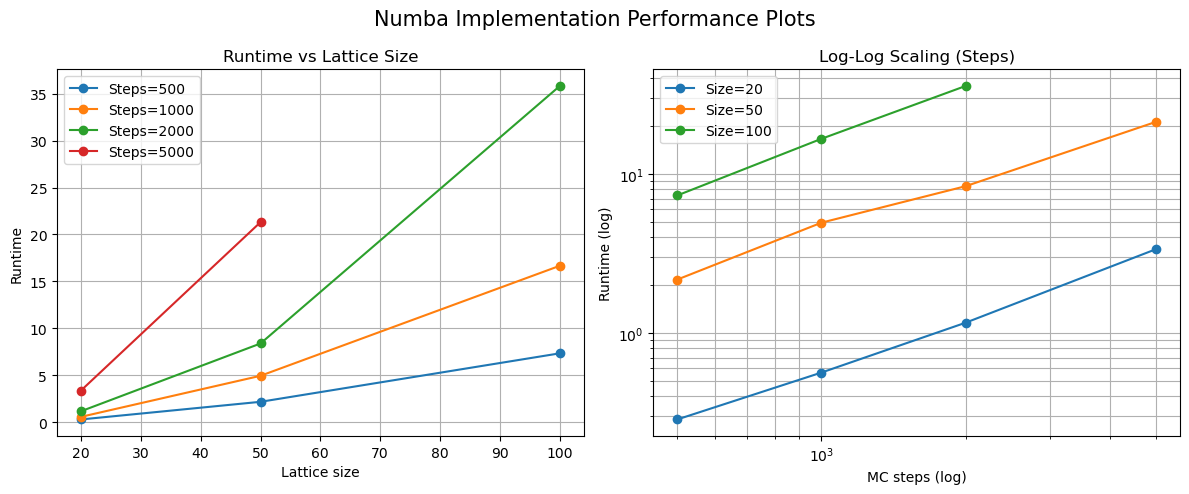

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Runtime vs Lattice Size
for steps in sorted(df["nsteps"].unique()):
    subset = df[df["nsteps"] == steps]
    ax[0].plot(subset["nmax"], subset["runtime"], marker="o", label=f"Steps={steps}")

ax[0].set_xlabel("Lattice size")
ax[0].set_ylabel("Runtime")
ax[0].set_title("Runtime vs Lattice Size")
ax[0].legend()
ax[0].grid(True)


# Runtime vs Steps (log-log)
for size in sorted(df["nmax"].unique()):
    subset = df[df["nmax"] == size]
    ax[1].loglog(subset["nsteps"], subset["runtime"], marker="o", label=f"Size={size}")

ax[1].set_xlabel("MC steps (log)")
ax[1].set_ylabel("Runtime (log)")
ax[1].set_title("Log-Log Scaling (Steps)")
ax[1].legend()
ax[1].grid(True, which="both")

fig.suptitle('Numba Implementation Performance Plots',size = 15)
plt.tight_layout()
plt.show()


In [33]:
# build a table 